# Wine Quality Dataset: Clasificación y Regresión de Calidad de Vino

En este notebook predeciremos la “calidad” del vino tanto como variable continua (regresión) como una categoría (clasificación), usando regresión logística, lineal y Random Forest.

## Conceptos principales
- **Clasificación binaria**: Cuando transformamos la calidad en “alta” o “baja”
- **Regresión**: Predicción directa del score de calidad
- **Datos desbalanceados**: Cuando tienes muchas más muestras de una clase que de otra


In [1]:
# Importar librerías y cargar datos
import pandas as pd  # Para manejar tablas de datos
import matplotlib.pyplot as plt  # Para hacer gráficos
import seaborn as sns  # Para gráficos estadísticos

# Cargamos el archivo CSV con los datos de vinos
df_r = pd.read_csv('winequality-red.csv', sep=';')
df_w = pd.read_csv('winequality-white.csv', sep=';')
df = pd.concat([df_r, df_w], ignore_index=True)
# Mostramos el shape de los datos separados y combinados
print("Datos de vino tinto:", df_r.shape)
print("Datos de vino blanco:", df_w.shape)
print("Datos combinados:", df.shape)
# Mostramos las primeras filas para ver cómo son los datos
print(df.head())
# Mostramos las últomas filas para ver cómo son los datos
print(df.tail())
# Mostramos información básica de los datos
print(df.info())
# Estadísticas descriptivas
print(df.describe())


Datos de vino tinto: (1599, 12)
Datos de vino blanco: (4898, 12)
Datos combinados: (6497, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0

### Observación
Revisa la estructura del dataset y piensa:
- ¿Qué variables podrías usar para predecir si un vino es bueno?


quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

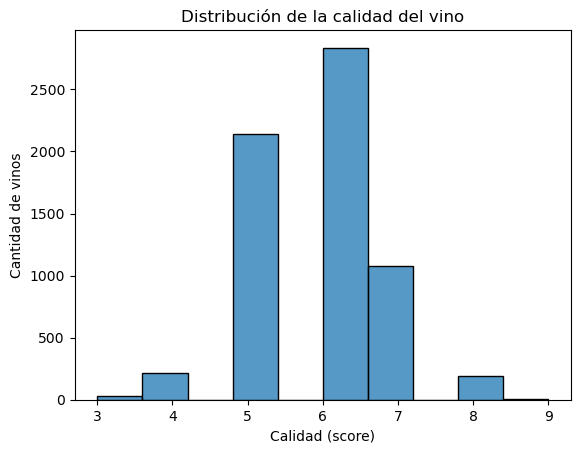

In [2]:
# Distribución de la variable 'quality'
# Esto nos ayuda a ver cuántos vinos hay de cada calidad
display(df['quality'].value_counts())

plt.title('Distribución de la calidad del vino')
sns.histplot(df['quality'], bins=10)
plt.title('Distribución de la calidad del vino')
plt.xlabel('Calidad (score)')
plt.ylabel('Cantidad de vinos')
plt.show()

# EXPLICACIÓN:
# El gráfico muestra cuántos vinos hay para cada puntuación de calidad.
# Si ves que la mayoría de vinos tienen una calidad similar, significa que los datos están desbalanceados.
# Esto puede afectar a los modelos, porque aprenderán mejor sobre la clase más frecuente.

**Pregunta para reflexionar:**  
- ¿La calidad está bien balanceada o predominan algunos valores?


In [3]:
# Transformación a clasificación binaria de calidad
# Creamos una nueva columna: 1 si la calidad es 7 o más (vino bueno), 0 si es menor (vino normal)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Vemos cuántos vinos buenos y normales hay
print(df['quality_label'].value_counts())


quality_label
0    5220
1    1277
Name: count, dtype: int64


**Clasificación binaria:**  
Nos ayuda a responder preguntas tipo "¿Este vino es bueno o malo?" en vez de predecir el score exacto.


In [4]:
# Split en entrenamiento/test para clasificación
# Separamos los datos en dos grupos: uno para entrenar el modelo y otro para probarlo
from sklearn.model_selection import train_test_split

# X son las variables que usaremos para predecir, y es la respuesta (vino bueno o no)
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

# 70% para entrenar, 30% para probar. random_state=42 hace que siempre salga igual.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Mostramos el tamaño de cada conjunto
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (4547, 11)
Tamaño del conjunto de prueba: (1950, 11)


In [5]:
# Normalizamos las variables para poder usar L2 regularization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Ahora X_train y X_test tienen las variables en una escala similar, lo que ayuda a los modelos.

Accuracy: 0.7496807151979565
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74      1591
           1       0.72      0.80      0.76      1541

    accuracy                           0.75      3132
   macro avg       0.75      0.75      0.75      3132
weighted avg       0.75      0.75      0.75      3132



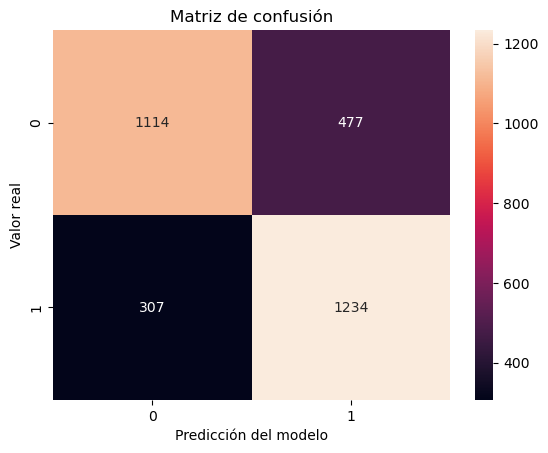

In [34]:
# Regresión logística: predicción binaria
# Este modelo intenta predecir si el vino es bueno (1) o no (0)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Creamos el modelo y lo entrenamos con los datos de entrenamiento
logreg = LogisticRegression(max_iter=1000, penalty='l2') # Usamos L2 regularization para evitar overfitting
logreg.fit(X_train, y_train)

# Hacemos predicciones con los datos de prueba
y_pred = logreg.predict(X_test)

# Mostramos qué porcentaje acierta el modelo
print('Accuracy:', accuracy_score(y_test, y_pred))

# Mostramos un reporte más detallado (precisión, recall, etc.)
print('Reporte de clasificación:\n', classification_report(y_test, y_pred))

# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

# EXPLICACIÓN:
# La matriz de confusión te muestra cuántos vinos fueron clasificados correctamente y cuántos no.
# - Diagonal principal: aciertos (predicción igual a realidad).
# - Fuera de la diagonal: errores (falsos positivos o negativos).
# Así puedes ver si el modelo confunde más los vinos buenos o los normales.

**¿Cómo se evalúa un modelo de clasificación?**  
- Accuracy: % de aciertos totales
- Matriz de confusión: muestra falsos positivos/negativos y verdaderos positivos/negativos.

### ¿Cómo interpretar la matriz de confusión?

- **Fila 0 (Valor real = 0):** Vinos que en realidad NO son buenos.
  - **Columna 0:** El modelo predijo correctamente que NO son buenos (aciertos, llamados "verdaderos negativos").
  - **Columna 1:** El modelo se equivocó y dijo que eran buenos (errores, llamados "falsos positivos").

- **Fila 1 (Valor real = 1):** Vinos que en realidad SÍ son buenos.
  - **Columna 0:** El modelo se equivocó y dijo que NO eran buenos (errores, llamados "falsos negativos").
  - **Columna 1:** El modelo acertó y dijo que SÍ eran buenos (aciertos, llamados "verdaderos positivos").

En resumen:
- **Diagonal principal:** Aciertos (predicción igual a realidad).
- **Fuera de la diagonal:** Errores.

Esto te ayuda a ver si el modelo confunde más los vinos buenos o los normales y si comete más errores de un tipo que de otro.

El modelo tiene muy buen desempeño al predecir la clase 0, pero falla en muchos casos de la clase 1.
Esto puede indicar:

Desbalance de clases (muchos más 0 que 1).

O que el modelo no está captando bien las características de la clase 1.

Primeros 10 con respecto a las Predicciones de calidad (primeros 10): [8 5 7 6 6 6 5 6 5 7] [6.65 5.   6.29 5.71 5.41 6.19 6.09 6.11 5.1  6.33]
RMSE: 0.7297748740347622
F1-score: 0.3687150837988827


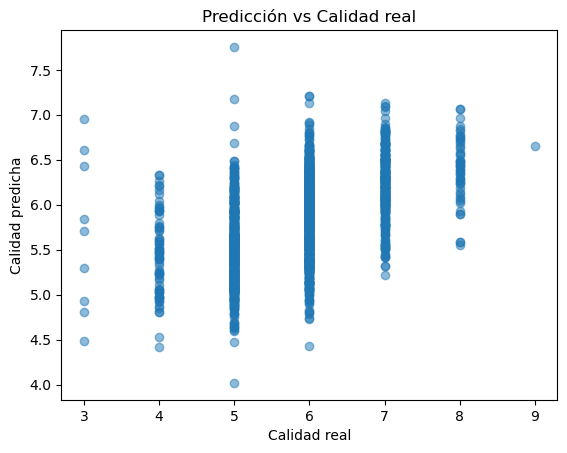

In [7]:
# Regresión lineal: predicción del score de calidad
# Aquí intentamos predecir el valor exacto de la calidad (no solo bueno/malo)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

y_reg = df['quality']  # La variable que queremos predecir
X_reg = df.drop(columns=['quality', 'quality_label'])  # Usamos las mismas variables que antes

# Separamos en entrenamiento y test
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Creamos y entrenamos el modelo de regresión lineal
reg = LinearRegression()
reg.fit(Xr_train, yr_train)

# Hacemos predicciones
yr_pred = reg.predict(Xr_test)
print('Primeros 10 con respecto a las Predicciones de calidad (primeros 10):', yr_test[:10].values, yr_pred[:10].round(2))
# Calculamos el error cuadrático medio (RMSE)
import numpy as np
print('RMSE:', np.sqrt(mean_squared_error(yr_test, yr_pred)))
# Vamos a calcular el F1-score y analizar el posible desbalance de clase
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)   
print('F1-score:', f1)
# EXPLICACIÓN:
# El RMSE (Root Mean Squared Error) indica cuánto se equivoca el modelo al predecir la calidad.
# Un valor más bajo significa que el modelo predice mejor.
# Si quieres visualizar la relación entre predicción y realidad, puedes hacer un scatterplot así:
plt.scatter(yr_test, yr_pred, alpha=0.5)
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Predicción vs Calidad real')
plt.show()
# Si los puntos están cerca de la línea diagonal, el modelo predice bien.

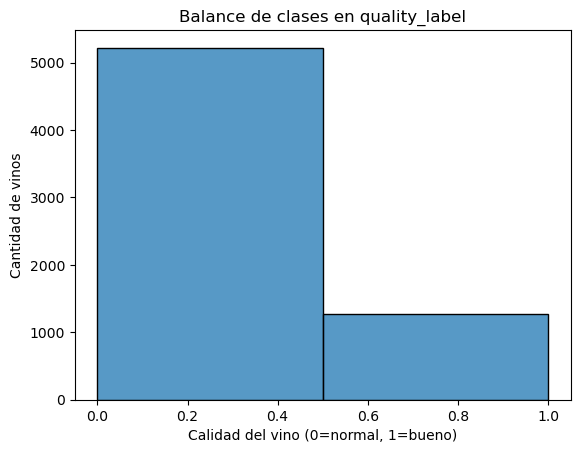

In [8]:
# Análisis del balance de clases
import matplotlib.pyplot as plt
sns.histplot(df['quality_label'], bins=2)
plt.title('Balance de clases en quality_label')
plt.xlabel('Calidad del vino (0=normal, 1=bueno)')
plt.ylabel('Cantidad de vinos')
plt.show()

Solo 13% de los datos son de la clase 1,
mientras que 87% son de la clase 0 → hay fuerte desbalance.

## Recomendaciones:

* Aplicar re-muestreo:

    - Oversampling de la clase 1 (por ejemplo con SMOTE).

    - O undersampling de la clase 0.

* Usar métricas más robustas al desbalance, como:

    - ROC-AUC, Precision-Recall AUC, o Balanced Accuracy.

* Ajustar el umbral de decisión del modelo para mejorar el recall.

    - Considerar ponderar las clases (class weights) durante el entrenamiento.

**¿Por qué puede ser útil la regresión aquí?**  
Permite anticipar la puntuación exacta y analizar si algunas propiedades químicas influyen más en la calidad que otras.


In [23]:
# Vamos a aplicar dos modelos adicionales: Árbol de Decisión, SVM y Random Forest
# Estos modelos se usan para validar y mejorar el rendimiento del modelo de Regresión Lineal.
# El objetivo es predecir el valor de calidad del vino basado en sus características.

# Importar bibliotecas necesarias
from sklearn.ensemble import RandomForestClassifier
# from sklearn._modellinear
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# Implementamos los tres modelos adicionales para clasificación
model = {
    'Regresión Logística': LogisticRegression(max_iter=1000, penalty='l2'),
    'Decision Tree': DecisionTreeClassifier(), 
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier()
}

for name, mod in model.items():
    # Entrenamos el modelo
    mod.fit(X_train, y_train)
    # Hacemos predicciones
    y_pred = mod.predict(X_test)
    # Mostramos qué porcentaje acierta el modelo
    print(f'--- {name} ---')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    # Mostramos un reporte más detallado (precisión, recall, etc.)
    print('Reporte de clasificación:\n', classification_report(y_test, y_pred))


--- Regresión Logística ---
Accuracy: 0.8261538461538461
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90      1585
           1       0.58      0.27      0.37       365

    accuracy                           0.83      1950
   macro avg       0.71      0.61      0.63      1950
weighted avg       0.80      0.83      0.80      1950

--- Decision Tree ---
Accuracy: 0.8369230769230769
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      1585
           1       0.56      0.62      0.59       365

    accuracy                           0.84      1950
   macro avg       0.73      0.75      0.74      1950
weighted avg       0.84      0.84      0.84      1950

--- SVM ---
Accuracy: 0.837948717948718
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91      1585
        

In [25]:
# Comparamos los cuatro modelos en términos de accuracy, f1-score, RMSE y visualizamos los resultados.
# EXPLICACIÓN:
# Aquí comparamos los modelos para ver cuál funciona mejor en la predicción de la calidad del vino.
from sklearn.metrics import mean_squared_error
for name, mod in model.items():
    # Entrenamos el modelo
    mod.fit(Xr_train, yr_train)
    # Hacemos predicciones
    yr_pred = mod.predict(Xr_test)
    # Calculamos el error cuadrático medio (RMSE)
    rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
    mse = mean_squared_error(yr_test, yr_pred)
    f1 = f1_score(y_test, y_pred)
    print(f'--- {name} ---')
    # Visualizacos los resultados con dos decimales
    print(f'RMSE: {rmse:.2f}, MSE: {mse:.2f}, F1-score: {f1:.2f}')
    

--- Regresión Logística ---
RMSE: 0.80, MSE: 0.63, F1-score: 0.64
--- Decision Tree ---
RMSE: 0.87, MSE: 0.76, F1-score: 0.64
--- SVM ---
RMSE: 0.88, MSE: 0.77, F1-score: 0.64
--- Random Forest ---
RMSE: 0.66, MSE: 0.43, F1-score: 0.64


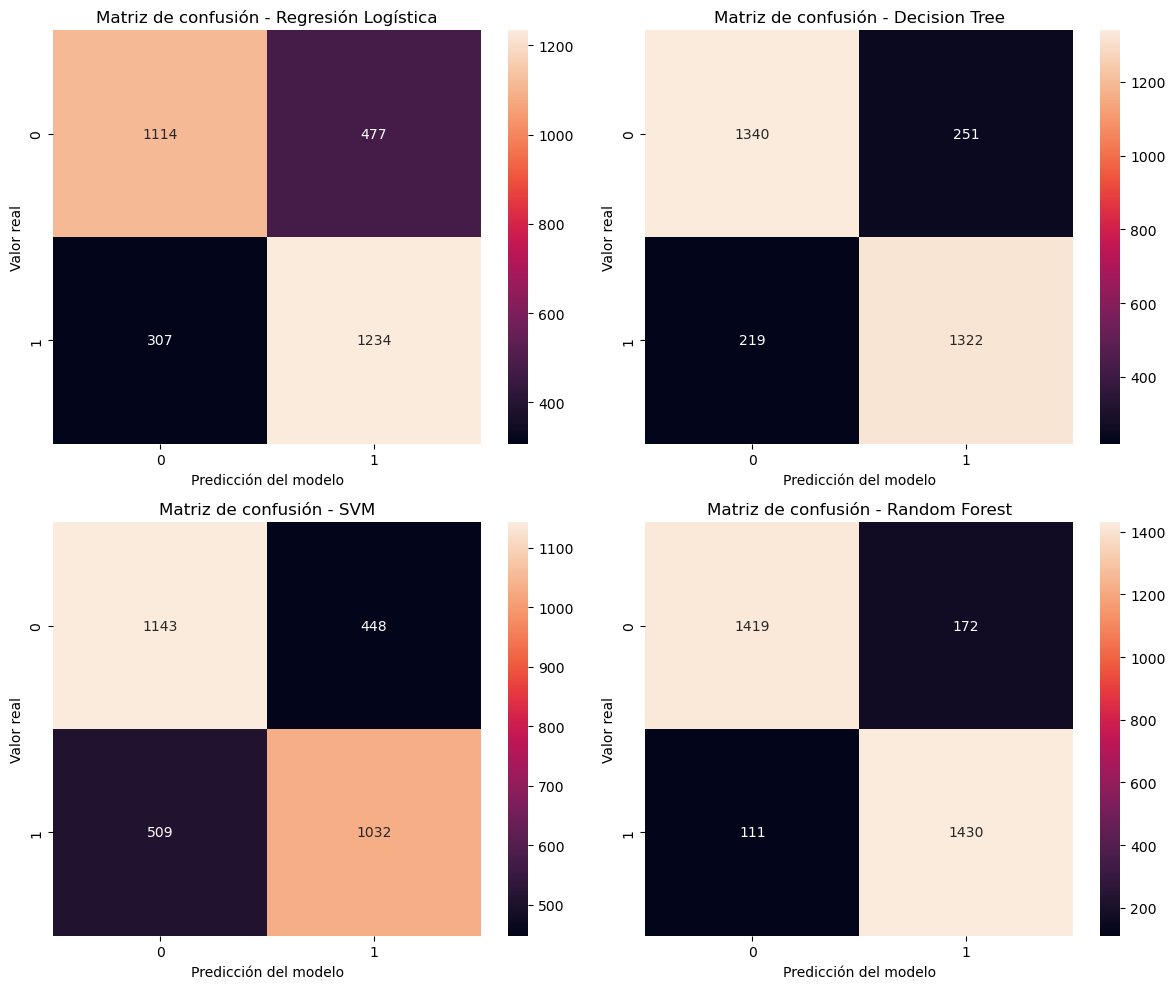

In [35]:
# Crearemos un subplot para visualizar las cutro matrices de confusión juntas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, mod) in zip(axes.flatten(), model.items()):
    # Entrenamos el modelo
    mod.fit(X_train, y_train)
    # Hacemos predicciones
    y_pred = mod.predict(X_test)
    # Mostramos la matriz de confusión: cuántos aciertos y errores
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=ax)
    ax.set_title(f'Matriz de confusión - {name}')
    ax.set_xlabel('Predicción del modelo')
    ax.set_ylabel('Valor real')
plt.tight_layout()
plt.show()

In [28]:
# Creamos un oversamplint usando SMOTE para balancear las clases
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y) 
print("Después de SMOTE, distribución de clases:", y_res.value_counts())
# Ahora podemos repetir el proceso de split, entrenamiento y evaluación con los datos balanceados
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)
# Mostramos el tamaño de cada conjunto
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)


Después de SMOTE, distribución de clases: quality_label
0    5220
1    5220
Name: count, dtype: int64
Tamaño del conjunto de entrenamiento: (7308, 11)
Tamaño del conjunto de prueba: (3132, 11)


In [29]:
# Volvemos a entrenar y evaluar los modelos con los datos balanceados
for name, mod in model.items():
    # Entrenamos el modelo
    mod.fit(X_train, y_train)
    # Hacemos predicciones
    y_pred = mod.predict(X_test)
    # Mostramos qué porcentaje acierta el modelo
    print(f'--- {name} (datos balanceados) ---')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    

--- Regresión Logística (datos balanceados) ---
Accuracy: 0.7496807151979565
--- Decision Tree (datos balanceados) ---
Accuracy: 0.8505747126436781
--- SVM (datos balanceados) ---
Accuracy: 0.6944444444444444
--- Random Forest (datos balanceados) ---
Accuracy: 0.9048531289910601


In [30]:
# Volvemos a comparar los cuatro modelos en términos de accuracy, f1-score, RMSE y visualizamos los resultados.
for name, mod in model.items():
    # Entrenamos el modelo
    mod.fit(Xr_train, yr_train)
    # Hacemos predicciones
    yr_pred = mod.predict(Xr_test)
    # Calculamos el error cuadrático medio (RMSE)
    rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
    mse = mean_squared_error(yr_test, yr_pred)
    f1 = f1_score(y_test, y_pred)
    print(f'--- {name} ---')
    # Visualizacos los resultados con dos decimales
    print(f'RMSE: {rmse:.2f}, MSE: {mse:.2f}, F1-score: {f1:.2f}')

--- Regresión Logística ---
RMSE: 0.80, MSE: 0.63, F1-score: 0.91
--- Decision Tree ---
RMSE: 0.87, MSE: 0.75, F1-score: 0.91
--- SVM ---
RMSE: 0.88, MSE: 0.77, F1-score: 0.91
--- Random Forest ---
RMSE: 0.66, MSE: 0.43, F1-score: 0.91


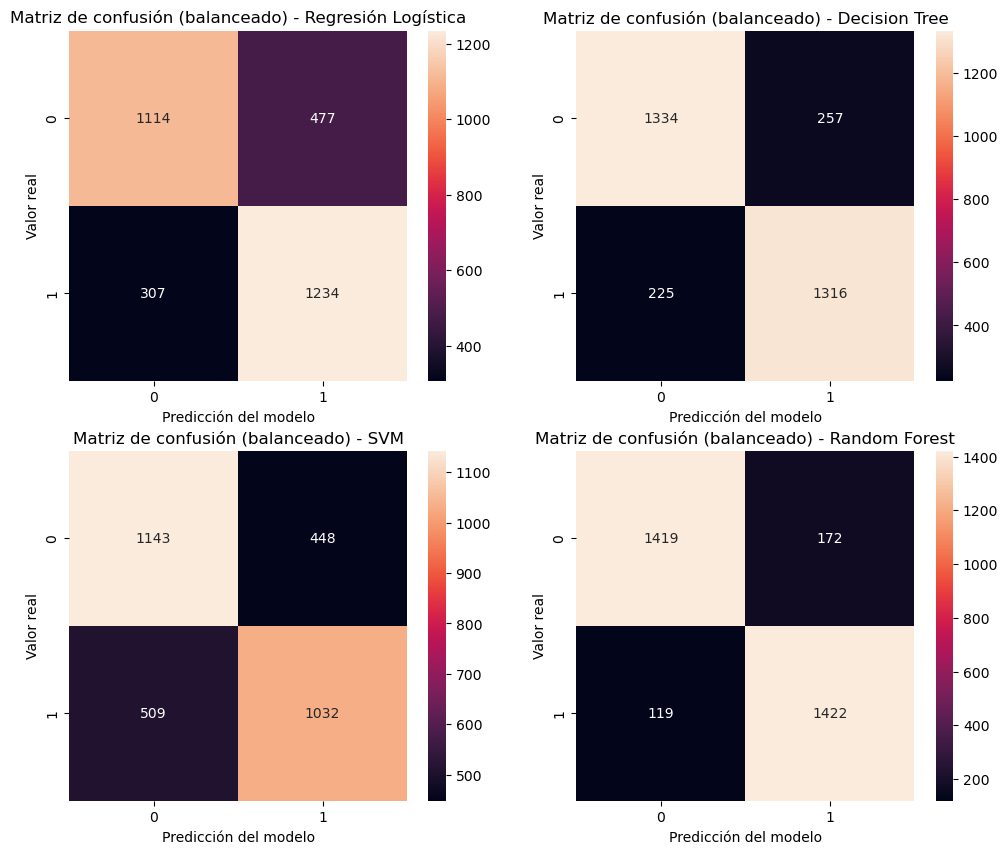

In [36]:
# Visulizamos los resultaos de las metricas de los modelos con datos balanceados
plt.rcParams['axes.formatter.useoffset'] = False
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, mod) in zip(axes.flatten(), model.items()):
    # Entrenamos el modelo
    mod.fit(X_train, y_train)
    # Hacemos predicciones
    y_pred = mod.predict(X_test)
    # Mostramos la matriz de confusión: cuántos aciertos y errores
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=ax)
    ax.set_title(f'Matriz de confusión (balanceado) - {name}')
    ax.set_xlabel('Predicción del modelo')
    ax.set_ylabel('Valor real')